# Data Loading

In [106]:
import numpy as np
import pandas as pd
import os
import kagglehub

In [107]:
path = kagglehub.dataset_download("nelgiriyewithana/global-weather-repository")
df = pd.read_csv(os.path.join(path, "GlobalWeatherRepository.csv"))

pd.set_option('display.max_columns', None)

df.head()

100%|██████████| 11.4M/11.4M [00:00<00:00, 55.3MB/s]

Extracting files...


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [108]:
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Cities: {df['location_name'].nunique()}  |  Countries: {df['country'].nunique()}")

dates = pd.to_datetime(df['last_updated'], errors='coerce')
print(f"Date range: {dates.min().date()} to {dates.max().date()}")

144,042 rows, 41 columns
Cities: 257  |  Countries: 211
Date range: 2024-05-16 to 2026-05-28


In [109]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,144042.000000,144042.000000,1.440420e+05,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000,144042.000000
mean,19.220147,21.927988,1.747906e+09,21.251517,70.254505,7.978145,12.843317,169.014732,1014.052672,29.944383,0.132690,0.005028,66.788221,39.752996,22.110997,71.794550,9.514696,5.621478,3.255951,11.291236,18.173365,448.354500,57.480166,14.788031,10.092657,23.809471,47.695592,1.685189,2.573000,49.708731
std,24.411327,65.781188,1.850449e+07,9.612287,17.302011,7.103576,11.428770,103.680984,10.156986,0.299883,0.559681,0.022121,23.762799,34.068250,11.512615,20.720431,2.685320,1.676843,3.531813,8.486262,13.657232,741.426453,30.372750,23.275684,34.669843,36.197597,147.177007,0.933054,2.420859,35.014189
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,0.000000,0.000000,2.000000,0.000000,-36.700000,-34.000000,0.000000,0.000000,0.000000,2.200000,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731920e+09,15.700000,60.200000,3.800000,6.100000,80.000000,1010.000000,29.830000,0.000000,0.000000,51.000000,0.000000,15.700000,60.300000,10.000000,6.000000,0.100000,6.300000,10.200000,194.250000,38.000000,1.800000,1.110000,7.030000,9.805000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747904e+09,23.700000,74.600000,6.700000,10.800000,161.000000,1013.000000,29.930000,0.000000,0.000000,72.000000,29.000000,25.100000,77.100000,10.000000,6.000000,1.800000,9.500000,15.300000,286.750000,55.000000,5.735000,2.405000,13.875000,19.600000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.763882e+09,27.900000,82.300000,11.000000,17.600000,256.000000,1018.000000,30.060000,0.020000,0.000000,86.000000,75.000000,29.900000,85.800000,10.000000,6.000000,6.000000,15.000000,24.100000,449.550000,73.000000,17.020000,8.050000,27.350000,40.804000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.779949e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,42.240000,1.660000,100.000000,100.000000,81.300000,178.300000,32.000000,19.000000,16.300000,1845.700000,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [110]:
# copy to compare original values against
df_raw = df.copy()

# Data Cleaning, Preprocessing & Validation

## Missing Values
- The dataset initially contained no standard missing values.
- During datetime conversion, some moonrise and moonset entries became NaT.
- Investigation showed these corresponded to meaningful non-time astronomical states such as "No moonrise" and "Does not set today".
- These values were intentionally preserved as NaT rather than imputed with artificial times.

In [111]:
# Checking for missing values
df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [112]:
# No missing values

# Checking for duplicated rows
df.duplicated().sum()

np.int64(0)

## Checking for outliers and handling consistency issues

### Time related features

#### Datatype conversions

In [113]:
# Understanding the data types
df.dtypes

country                             str
location_name                       str
latitude                        float64
longitude                       float64
timezone                            str
last_updated_epoch                int64
last_updated                        str
temperature_celsius             float64
temperature_fahrenheit          float64
condition_text                      str
wind_mph                        float64
wind_kph                        float64
wind_degree                       int64
wind_direction                      str
pressure_mb                     float64
pressure_in                     float64
precip_mm                       float64
precip_in                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
feels_like_fahrenheit           float64
visibility_km                   float64
visibility_miles                float64
uv_index                        float64


In [114]:
# last_updated - should be time, not str
# sunrise, sunset - should be time, not str
# moonrise, moonset - should be time, not str

time_columns = [
    'last_updated',
    'sunrise',
    'sunset',
    'moonrise',
    'moonset'
]

for col in time_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

C:\Users\kmddg\AppData\Local\Temp\ipykernel_69056\2784425753.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\kmddg\AppData\Local\Temp\ipykernel_69056\2784425753.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\kmddg\AppData\Local\Temp\ipykernel_69056\2784425753.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\kmddg\AppData\Local\Temp\ipykernel_69056\2784425753.py:14: UserWarning: Coul

In [115]:
# check if there were any error in conversion
df[time_columns].isna().sum()

last_updated       0
sunrise            0
sunset             0
moonrise        4876
moonset         4895
dtype: int64

In [116]:
# moonrise, moonset have problematic values - diagnose
df_raw.loc[df['moonrise'].isna(), 'moonrise'].value_counts().head(10)

moonrise
No moonrise    4838
....             16
****             13
24:00             9
Name: count, dtype: int64

In [117]:
# 24:00 also means Moon did not rise that day, so we can replace it with NaT
# Similar for moonset

df_raw.loc[df['moonset'].isna(), 'moonset'].value_counts().head(10)

moonset
No moonset            4749
Does not set today     114
....                    16
****                    13
24:00                    3
Name: count, dtype: int64

In [118]:
df.dtypes

country                                    str
location_name                              str
latitude                               float64
longitude                              float64
timezone                                   str
last_updated_epoch                       int64
last_updated                    datetime64[us]
temperature_celsius                    float64
temperature_fahrenheit                 float64
condition_text                             str
wind_mph                               float64
wind_kph                               float64
wind_degree                              int64
wind_direction                             str
pressure_mb                            float64
pressure_in                            float64
precip_mm                              float64
precip_in                              float64
humidity                                 int64
cloud                                    int64
feels_like_celsius                     float64
feels_like_fa

In [119]:
df.shape

(144042, 41)

### Temperature related features and TARGET FEATURE

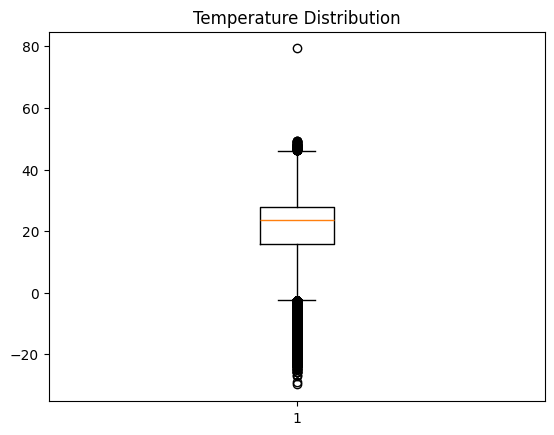

In [120]:
# temperature distribution
import matplotlib.pyplot as plt

plt.boxplot(df['temperature_celsius'])
plt.title('Temperature Distribution')
plt.show()

(array([2.0000e+00, 0.0000e+00, 2.0000e+00, 5.0000e+00, 7.0000e+00,
        1.6000e+01, 1.4000e+01, 2.8000e+01, 2.9000e+01, 4.6000e+01,
        4.6000e+01, 5.2000e+01, 5.8000e+01, 5.7000e+01, 6.1000e+01,
        5.9000e+01, 7.2000e+01, 7.7000e+01, 1.0200e+02, 1.4200e+02,
        1.8100e+02, 2.1200e+02, 2.5800e+02, 3.6300e+02, 4.3400e+02,
        5.6100e+02, 7.2900e+02, 1.0420e+03, 1.1580e+03, 1.3350e+03,
        1.6190e+03, 1.9040e+03, 2.1200e+03, 1.8910e+03, 2.3880e+03,
        2.5480e+03, 2.6290e+03, 2.8230e+03, 2.7150e+03, 2.6780e+03,
        2.8130e+03, 3.3850e+03, 3.9090e+03, 4.3270e+03, 3.9110e+03,
        5.2330e+03, 5.3240e+03, 5.7940e+03, 6.8110e+03, 8.1930e+03,
        9.4580e+03, 9.6490e+03, 1.0085e+04, 9.5900e+03, 6.9190e+03,
        4.4200e+03, 3.8510e+03, 2.5390e+03, 1.7580e+03, 1.4460e+03,
        1.0290e+03, 7.7500e+02, 5.8300e+02, 5.3100e+02, 4.0300e+02,
        2.8200e+02, 2.0800e+02, 1.5200e+02, 1.0100e+02, 6.1000e+01,
        2.1000e+01, 1.1000e+01, 6.0000e+00, 0.00

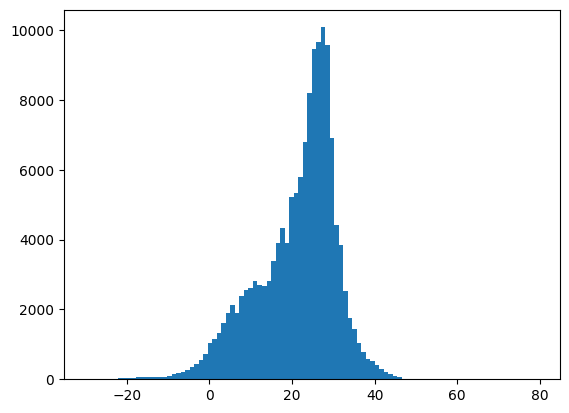

In [121]:
# temperature celsius - bell curve

plt.hist(df['temperature_celsius'], bins=100)

In [122]:
# IQR method to detect outliers in temperature_celsius

Q1 = df['temperature_celsius'].quantile(0.25)
Q3 = df['temperature_celsius'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['temperature_celsius'] < lower) |
    (df['temperature_celsius'] > upper)
]

print(outliers.shape)

(2381, 41)


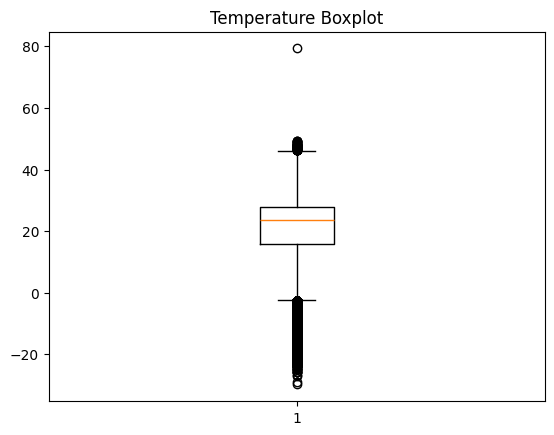

In [123]:
plt.boxplot(df['temperature_celsius'])
plt.title('Temperature Boxplot')
plt.show()

In [124]:
outliers.sort_values(
    'temperature_celsius'
).head(20)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
118990,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1768719600,2026-01-18 15:00:00,-29.8,-21.6,Mist,4.0,6.5,343,NNW,1029.0,30.39,0.0,0.0,56,0,-36.7,-34.0,10.0,6.0,0.6,8.5,13.6,207.85,72.0,4.250,10.850,9.150,9.350,1,1,2026-05-28 08:35:00,2026-05-28 17:31:00,2026-05-28 08:39:00,2026-05-28 16:36:00,Waning Crescent,1
119182,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1768893300,2026-01-20 15:15:00,-28.9,-20.0,Sunny,4.0,6.5,280,W,1027.0,30.33,0.0,0.0,62,0,-35.6,-32.1,8.0,4.0,1.0,4.7,7.6,1915.85,26.0,42.650,41.450,59.450,60.650,3,8,2026-05-28 08:33:00,2026-05-28 17:34:00,2026-05-28 09:33:00,2026-05-28 19:04:00,Waxing Crescent,1
121617,Belarus,Minsk,53.9000,27.5667,Europe/Minsk,1770015600,2026-02-02 10:00:00,-26.9,-16.4,Freezing fog,6.9,11.2,331,NNW,1019.0,30.09,0.0,0.0,83,0,-36.0,-32.8,10.0,6.0,0.2,14.6,23.4,237.85,47.0,7.950,3.950,10.350,14.950,1,1,2026-05-28 08:55:00,2026-05-28 17:53:00,2026-05-28 18:36:00,2026-05-28 09:24:00,Waning Gibbous,100
118606,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1768547700,2026-01-16 15:15:00,-26.8,-16.2,Mist,3.8,6.1,74,ENE,1021.0,30.15,0.0,0.0,69,0,-32.9,-27.3,10.0,6.0,0.6,8.0,12.9,745.85,68.0,12.450,47.550,14.250,14.950,1,2,2026-05-28 08:36:00,2026-05-28 17:28:00,2026-05-28 07:09:00,2026-05-28 14:30:00,Waning Crescent,9
118801,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1768633200,2026-01-17 15:00:00,-25.9,-14.6,Partly cloudy,4.0,6.5,341,NNW,1019.0,30.09,0.0,0.0,69,50,-32.2,-25.9,8.0,4.0,0.5,8.5,13.6,348.85,69.0,10.650,15.250,17.050,17.350,2,2,2026-05-28 08:36:00,2026-05-28 17:30:00,2026-05-28 07:59:00,2026-05-28 15:29:00,Waning Crescent,5
118507,Belarus,Minsk,53.9000,27.5667,Europe/Minsk,1768547700,2026-01-16 10:15:00,-25.8,-14.4,Freezing fog,4.3,6.8,146,SSE,1035.0,30.56,0.0,0.0,76,25,-32.3,-26.1,9.0,5.0,0.0,8.9,14.4,380.85,13.0,30.750,9.750,26.950,27.550,2,3,2026-05-28 09:19:00,2026-05-28 17:21:00,2026-05-28 08:24:00,2026-05-28 14:13:00,Waning Crescent,8
115680,Russia,Chi-Chi-Erh,51.7000,94.4500,Asia/Krasnoyarsk,1767251700,2026-01-01 14:15:00,-25.8,-14.4,Mist,2.2,3.6,235,SW,1048.0,30.95,0.0,0.0,94,78,-25.8,-14.4,2.0,1.0,0.6,2.3,3.8,161.85,73.0,6.650,3.550,12.550,14.250,1,2,2026-05-28 07:35:00,2026-05-28 17:20:00,2026-05-28 14:58:00,2026-05-28 05:27:00,Waxing Gibbous,90
118774,Kazakhstan,Astana,51.1811,71.4278,Asia/Almaty,1768633200,2026-01-17 12:00:00,-25.7,-14.3,Partly Cloudy,4.9,7.9,124,SE,1047.0,30.92,0.0,0.0,76,0,-32.9,-27.2,10.0,6.0,1.0,8.9,14.4,360.85,35.0,23.050,21.950,7.350,7.650,1,1,2026-05-28 08:10:00,2026-05-28 16:39:00,2026-05-28 07:47:00,2026-05-28 14:35:00,Waning Crescent,4
119376,Mongolia,Ulaanbaatar,47.9167,106.9167,Asia/Ulaanbaatar,1768978800,2026-01-21 15:00:00,-25.7,-14.3,Partly Cloudy,2.2,3.6,209,SSW,1023.0,30.21,0.0,0.0,57,0,-29.3,-20.8,6.0,3.0,0.8,6.7,10.8,1387.85,8.0,61.850,26.450,81.450,82.850,4,10,2026-05-28 08:32:00,2026-05-28 17:35:00,2026-05-28 09:52:00,2026-05-28 20:19:00,Waxing Crescent,3
120074,Canada,Ottawa,45.4167,-75.7000,America/Toronto,1769324400,2026-01-25 02:00:00,-25.0,-13.0,Partly cloudy,2.5,4.0,44,NE,1038.0,30.65,0.0,0.0,63,50,-28.9,-20.1,24.0,14.0,0.0,5.2,8.3,502.85,25.0,38.350,8.550,14.050,14.350,1,2,2026-05-28 07:31:00,2026-05-28 17:00:00,2026-05-28 10:22:00,NaT,First Quarter,39


In [125]:
outliers.sort_values(
    'temperature_celsius',
    ascending=False
).head(20)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
137276,Fiji Islands,Suva,-18.1333,178.4167,Pacific/Fiji,1777012200,2026-04-24 18:30:00,79.3,174.7,Partly cloudy,10.1,16.2,121,ESE,1013.0,29.91,0.99,0.04,7,50,81.3,178.3,10.0,6.0,0.0,16.8,27.1,75.85,13.0,2.750,1.350,4.250,5.950,1,1,2026-05-28 06:18:00,2026-05-28 17:51:00,2026-05-28 12:53:00,NaT,First Quarter,43
6896,Kuwait,Kuwait City,29.3700,47.9600,Asia/Kuwait,1718804700,2024-06-19 16:45:00,49.2,120.6,Sunny,13.6,22.0,330,NNW,996.0,29.42,0.00,0.00,4,0,51.2,124.2,14.0,8.0,10.0,24.3,39.2,208.60,135.9,3.700,0.800,33.600,187.000,2,3,2026-05-28 04:49:00,2026-05-28 18:50:00,2026-05-28 16:33:00,2026-05-28 02:17:00,Waxing Gibbous,90
7460,Iraq,Baghdad,33.3400,44.3900,Asia/Baghdad,1719063900,2024-06-22 16:45:00,49.1,120.4,Partly cloudy,6.9,11.2,200,SSW,994.0,29.36,0.00,0.00,8,25,51.1,124.0,10.0,6.0,11.0,11.1,17.8,208.60,148.8,3.800,2.300,16.100,47.900,2,2,2026-05-28 04:54:00,2026-05-28 19:16:00,2026-05-28 20:06:00,2026-05-28 04:42:00,Full Moon,100
11145,Iraq,Baghdad,33.3400,44.3900,Asia/Baghdad,1720701900,2024-07-11 15:45:00,49.1,120.3,Sunny,12.8,20.5,307,NW,999.0,29.50,0.00,0.00,6,0,51.1,123.9,10.0,6.0,11.0,14.7,23.6,210.30,157.4,4.200,3.600,12.300,39.500,1,2,2026-05-28 05:02:00,2026-05-28 19:14:00,2026-05-28 09:58:00,2026-05-28 22:37:00,Waxing Crescent,23
8425,Kuwait,Kuwait City,29.3700,47.9600,Asia/Kuwait,1719494100,2024-06-27 16:15:00,48.9,120.0,Sunny,13.6,22.0,310,NW,993.0,29.33,0.00,0.00,4,0,50.9,123.6,9.7,6.0,10.0,29.6,47.6,198.60,140.2,5.800,3.000,29.000,133.500,2,3,2026-05-28 04:51:00,2026-05-28 18:52:00,2026-05-28 23:08:00,2026-05-28 10:13:00,Waning Gibbous,71
85049,Kuwait,Kuwait City,29.3667,47.9600,Asia/Kuwait,1753691400,2025-07-28 11:30:00,48.8,119.8,Sunny,2.2,3.6,225,SW,995.0,29.38,0.00,0.00,5,0,50.8,123.4,10.0,6.0,10.5,3.6,5.7,530.95,66.0,37.555,15.725,100.640,503.015,4,10,2026-05-28 05:06:00,2026-05-28 18:43:00,2026-05-28 08:26:00,2026-05-28 21:03:00,Waxing Crescent,11
11338,Iraq,Baghdad,33.3400,44.3900,Asia/Baghdad,1720788300,2024-07-12 15:45:00,48.8,119.8,Sunny,22.4,36.0,317,NW,995.0,29.39,0.00,0.00,6,0,50.8,123.4,10.0,6.0,11.0,25.7,41.4,196.90,183.1,2.800,11.200,18.400,50.600,2,2,2026-05-28 05:02:00,2026-05-28 19:14:00,2026-05-28 10:53:00,2026-05-28 23:01:00,Waxing Crescent,32
76862,Kuwait,Kuwait City,29.3667,47.9600,Asia/Kuwait,1750064400,2025-06-16 12:00:00,48.6,119.5,Sunny,8.1,13.0,305,NW,996.0,29.42,0.00,0.00,4,0,50.6,123.1,10.0,6.0,11.3,16.9,27.2,392.20,61.0,99.715,36.075,80.475,228.290,4,10,2026-05-28 04:48:00,2026-05-28 18:50:00,2026-05-28 22:51:00,2026-05-28 09:18:00,Waning Gibbous,80
7270,Iraq,Baghdad,33.3400,44.3900,Asia/Baghdad,1718976600,2024-06-21 16:30:00,48.4,119.1,Sunny,10.5,16.9,270,W,998.0,29.46,0.00,0.00,8,0,50.4,122.7,10.0,6.0,11.0,22.4,36.0,205.30,137.3,2.700,2.100,16.400,51.100,2,2,2026-05-28 04:53:00,2026-05-28 19:15:00,2026-05-28 19:06:00,2026-05-28 03:47:00,Full Moon,99
9975,Iraq,Baghdad,33.3400,44.3900,Asia/Baghdad,1720183500,2024-07-05 15:45:00,48.3,118.9,Sunny,21.7,34.9,330,NNW,995.0,29.38,0.00,0.00,6,0,50.3,122.5,10.0,6.0,11.0,23.2,37.3,212.00,186.0,3.000,8.100,23.200,97.300,2,2,2026-05-28 04:59:00,2026-05-28 19:16:00,2026-05-28 03:56:00,2026-05-28 19:16:00,New Moon,1


In [126]:
# All temperature outliers are plausible except Fiji
# Checking other records from Fiji

df_temp = df[df['location_name'] == 'Suva']
df_temp['temperature_celsius'].where(df_temp['temperature_celsius'] < 79).describe()

count    740.000000
mean      24.811622
std        2.207130
min       17.300000
25%       23.300000
50%       25.000000
75%       26.200000
max       30.400000
Name: temperature_celsius, dtype: float64

In [127]:
df[df['temperature_celsius'] > 79][
    [
        'country',
        'location_name',
        'temperature_celsius',
        'temperature_fahrenheit',
        'feels_like_celsius',
        'feels_like_fahrenheit'
    ]
]

,country,location_name,temperature_celsius,temperature_fahrenheit,feels_like_celsius,feels_like_fahrenheit
137276,Fiji Islands,Suva,79.3,174.7,81.3,178.3


In [128]:
# This record from Fiji with temperature > 79C has all other values regarding temperature similar to the outlier.
# Removing this record from the dataset

df = df[df['temperature_celsius'] <= 79]

In [129]:
df.shape

(144041, 41)

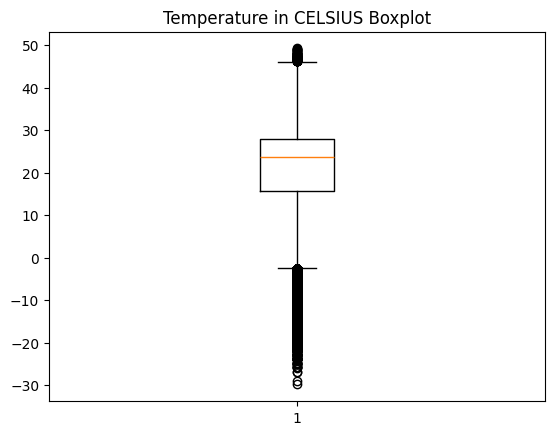

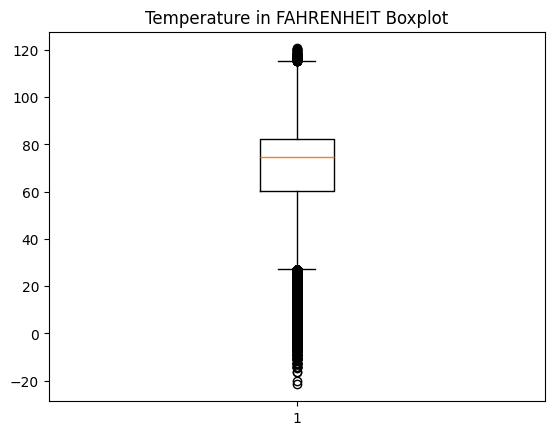

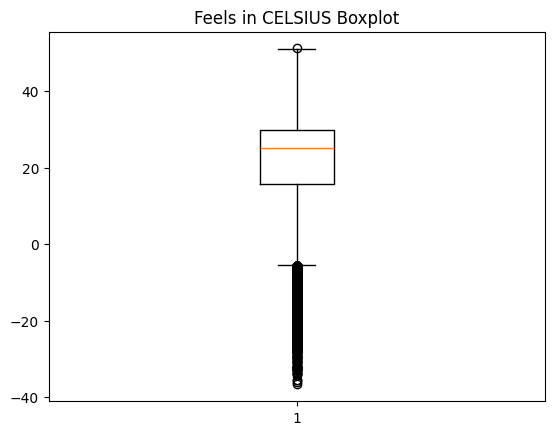

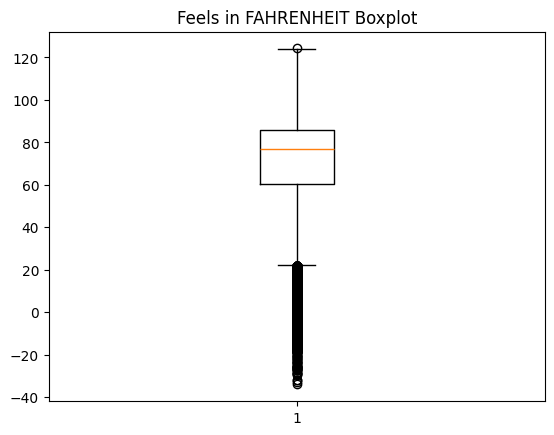

In [130]:
# checking for outliers in feels_like features using IQR method
# and comparing with temperature features to see if they are consistent

temperature_features = [
    'temperature_celsius',
    'temperature_fahrenheit',
    'feels_like_celsius',
    'feels_like_fahrenheit'
]

for col in temperature_features:
    plt.boxplot(df[col])
    plt.title(f'{col.split("_")[0].title()} in {col.split("_")[-1].upper()} Boxplot')
    plt.show()

### Location related features

In [131]:
countries = sorted(df['country'].unique())
display(countries)

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Bélgica',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Estonie',
 'Ethiopia',
 'Fiji Islands',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guatemala',
 'Guinea',
 'Guinea-Bissau',
 'Guya

In [132]:
cities = sorted(df['location_name'].unique())
display(cities) 

["'S Gravenjansdijk",
 "'S Gravenjansdyk",
 "'S Gravenstaffel",
 "'S-Gravenbrakel",
 '-Kingdom',
 'Abu Dhabi',
 'Abuja',
 'Accra',
 'Addis Ababa',
 'Addis Abeba',
 'Adkip',
 'Aguaray',
 'Airai',
 'Algiers',
 'Amman',
 'Amsterdam',
 'Andorra La Vella',
 'Ankara',
 'Antananarivo',
 'Apia',
 'Ar Riyadh',
 'Ashgabat',
 'Asmara',
 'Astana',
 'Asuncion',
 'Athens',
 'Aurora',
 'Bafoussam',
 'Baghdad',
 'Baku',
 'Bali',
 'Bamako',
 'Ban Lom',
 'Bandar Seri Begawan',
 'Bangkok',
 'Bangui',
 'Banjul',
 'Basseterre',
 'Beijing',
 'Beijing Shi',
 'Beirut',
 'Belgrade',
 'Belmopan',
 'Berlin',
 'Bern',
 'Bishkek',
 'Bissau',
 'Bogot',
 'Bogota',
 'Bras',
 'Bratislava',
 'Brazzaville',
 'Bridgetown',
 'Brussels',
 'Bucharest',
 'Budapest',
 'Buenos Aires',
 'Bujumbura',
 'Cairo',
 'Canberra',
 'Caracas',
 'Carreria',
 'Castries',
 'Chi Chi Khvar',
 'Chi-Chi-Erh',
 'City Of San Marino',
 'Colombo',
 'Conakry',
 'Copenhagen',
 'Costa Rica',
 'Dakar',
 'Damascus',
 'Dhaka',
 'Dhidhdhoo',
 'Dili',
 'Dj

In [133]:
print(len(countries), len(cities))

211 257


(array([7.390e+02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.478e+03, 7.380e+02,
        0.000e+00, 7.370e+02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 7.380e+02, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 7.380e+02, 1.480e+03, 1.000e+00, 1.198e+03, 0.000e+00,
        4.240e+02, 7.400e+02, 1.000e+01, 2.500e+01, 7.380e+02, 0.000e+00,
        9.940e+02, 7.590e+02, 7.400e+02, 7.400e+02, 1.478e+03, 0.000e+00,
        0.000e+00, 0.000e+00, 7.400e+02, 0.000e+00, 1.474e+03, 0.000e+00,
        0.000e+00, 7.360e+02, 7.380e+02, 7.350e+02, 0.000e+00, 0.000e+00,
        1.480e+03, 2.217e+03, 7.390e+02, 0.000e+00, 1.000e+00, 1.479e+03,
        0.000e+00, 0.000e+00, 7.380e+02, 1.477e+03, 7.410e+02, 0.000e+00,
        7.350e+02, 7.400e+02, 1.479e+03, 0.000e+00, 7.360e+02, 1.479e+03,
        7.400e+02, 0.000e+00, 7.380e+02, 7.390e+02, 7.750e+02, 1.037e+03,
        7.400e+02, 7.590e+02, 7.380e+0

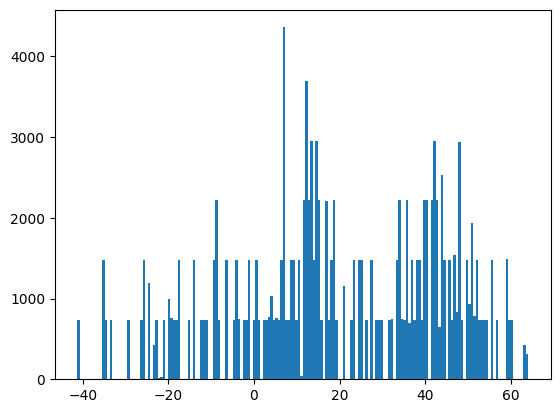

In [134]:
# check normal distribution for latitude

plt.hist(df['latitude'], bins=180)

In [135]:
df[(df['latitude'] > 60) | (df['latitude'] < -40)][
    ['country', 'location_name', 'latitude']
].drop_duplicates()

,country,location_name,latitude
59,Finland,Helsinki,60.1800
76,Iceland,Grindavik,63.8300
123,New Zealand,Wellington,-41.3000
7074,Iceland,Vestmannaeyjar,63.3700
8032,Iceland,Reykjavik,64.1500
27036,Finland,Helsinki,60.1756
27053,Iceland,Vestmannaeyjar,63.3650


(array([7.380e+02, 0.000e+00, 0.000e+00, 7.340e+02, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 7.150e+02, 0.000e+00,
        0.000e+00, 1.600e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 7.350e+02,
        0.000e+00, 0.000e+00, 0.000e+0

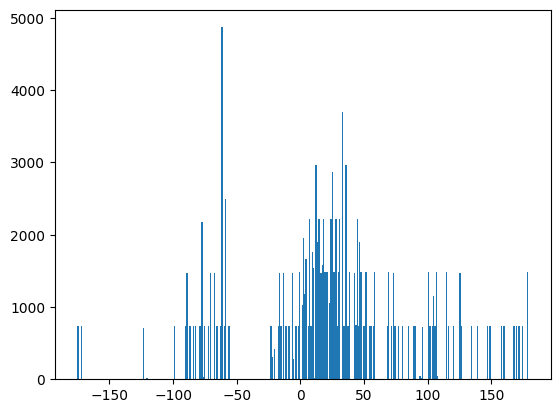

In [136]:
# check normal distribution for longitude

plt.hist(df['longitude'], bins=360)

Longitude distributions showed higher observation density around major populated continental regions, while sparse regions likely corresponded to oceanic areas with lower weather station or city representation.

In [137]:
df[(df['longitude'] > 150) | (df['longitude'] < -150)][
    ['country', 'location_name', 'longitude']
].drop_duplicates()

,country,location_name,longitude
58,Fiji Islands,Suva,178.4200
89,Kiribati,Tarawa,169.5300
107,Marshall Islands,Majuro,171.3800
111,Micronesia,Palikir,158.1500
123,New Zealand,Wellington,174.7800
148,Samoa,Apia,-171.7300
159,Solomon Islands,Honiara,159.9500
176,Tonga,Nuku`Aloia,-175.2000
181,Tuvalu,Funafuti,179.2200
189,Vanuatu,Port Vila,168.3200


In [138]:
display(df['timezone'].unique())

<StringArray>
[                    'Asia/Kabul',                  'Europe/Tirane',
                 'Africa/Algiers',                 'Europe/Andorra',
                  'Africa/Luanda',                'America/Antigua',
 'America/Argentina/Buenos_Aires',                   'Asia/Yerevan',
               'Australia/Sydney',                  'Europe/Vienna',
 ...
             'America/Hermosillo',                'Africa/Kinshasa',
                'Africa/Ndjamena',                   'Asia/Nicosia',
                 'Europe/Vatican',                  'Africa/Maseru',
              'Europe/San_Marino',                 'Africa/Abidjan',
               'Asia/Krasnoyarsk',                    'Europe/Kyiv']
Length: 199, dtype: str

In [139]:
df.isna().sum()

country                            0
location_name                      0
latitude                           0
longitude                          0
timezone                           0
last_updated_epoch                 0
last_updated                       0
temperature_celsius                0
temperature_fahrenheit             0
condition_text                     0
wind_mph                           0
wind_kph                           0
wind_degree                        0
wind_direction                     0
pressure_mb                        0
pressure_in                        0
precip_mm                          0
precip_in                          0
humidity                           0
cloud                              0
feels_like_celsius                 0
feels_like_fahrenheit              0
visibility_km                      0
visibility_miles                   0
uv_index                           0
gust_mph                           0
gust_kph                           0
a

In [140]:
df['condition_text'].unique()

<StringArray>
[                              'Partly Cloudy',
                               'Partly cloudy',
                                       'Sunny',
                               'Light drizzle',
                                       'Clear',
                                    'Overcast',
         'Moderate or heavy rain with thunder',
      'Patchy light rain in area with thunder',
                                         'Fog',
              'Patchy light rain with thunder',
                          'Patchy rain nearby',
                                  'Light rain',
                                        'Mist',
                                      'Cloudy',
                'Thundery outbreaks in nearby',
                               'Moderate rain',
                           'Light rain shower',
                      'Moderate rain at times',
               'Moderate or heavy rain shower',
                         'Heavy rain at times',
                          

### Wind related features

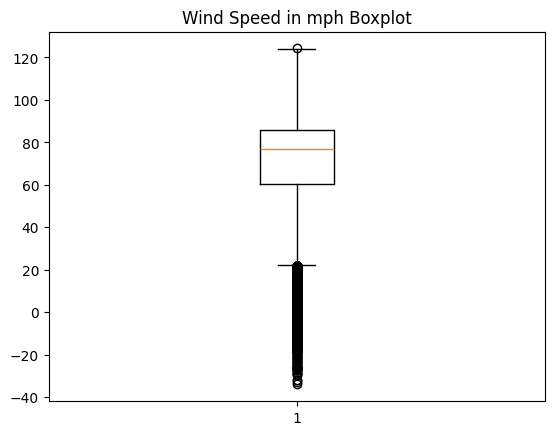

In [141]:
# boxplots for wind_mph and wind_kph

plt.boxplot(df[col])
plt.title('Wind Speed in mph Boxplot')
plt.show()

In [142]:
df['wind_mph'].where(df['wind_mph'] < 1750).describe()

count    144040.000000
mean          7.965403
std           5.208589
min           2.200000
25%           3.800000
50%           6.700000
75%          11.000000
max         169.100000
Name: wind_mph, dtype: float64

In [143]:
df[df['wind_mph'] > 1750]

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
7601,Burundi,Bujumbura,-3.38,29.36,Africa/Bujumbura,1719150300,2024-06-23 15:45:00,22.5,72.6,Partly cloudy,1841.2,2963.2,180,S,1014.0,29.94,0.0,0.0,52,25,24.6,76.3,10.0,6.0,7.0,1845.7,2970.4,277.0,52.2,0.6,0.2,5.3,7.2,1,1,2026-05-28 06:07:00,2026-05-28 18:03:00,2026-05-28 19:36:00,2026-05-28 07:19:00,Waning Gibbous,99


Historical maximum wind speed ever observed was recorded during Oklahoma Tornado on May 3, 1999 to be 321 mph (517 kph). Deleting this record as wind_mph, wind_kph, gust_mph and gust_kph all show implausible values.

In [144]:
df.shape

(144041, 41)

In [145]:
df = df[df['wind_mph'] < 400]

In [146]:
df.shape

(144040, 41)

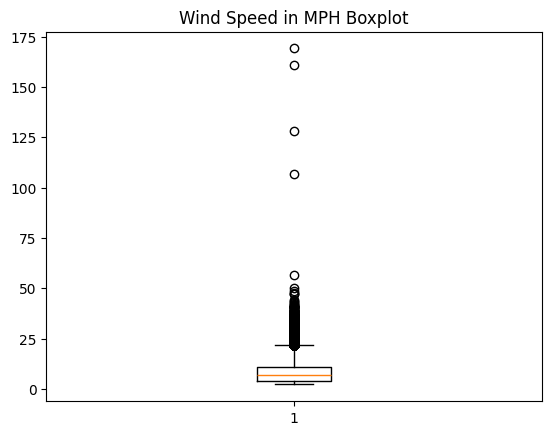

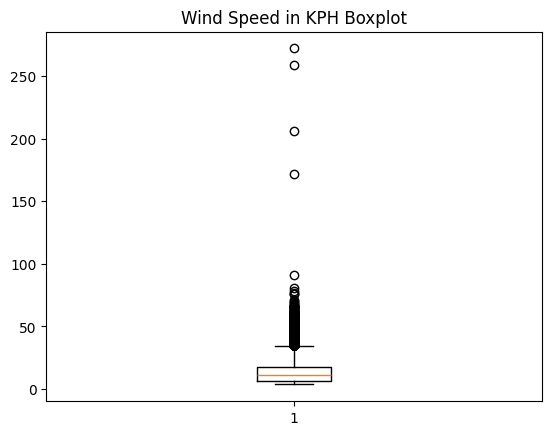

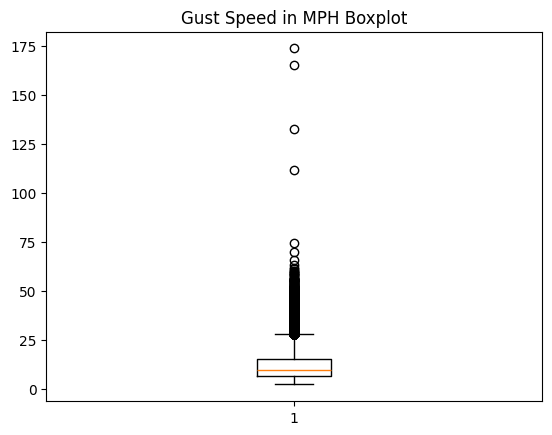

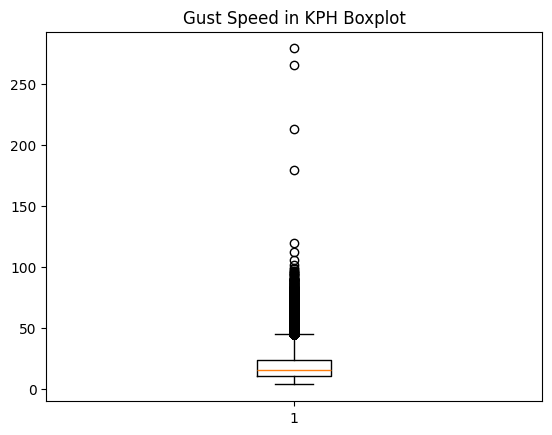

In [147]:
# boxplots for wind and gust speeds
# IQR method to detect outliers

wind_columns = ['wind_mph', 'wind_kph', 'gust_mph', 'gust_kph']

for col in wind_columns:
    plt.boxplot(df[col])
    plt.title(f'{col.split("_")[0].title()} Speed in {col.split("_")[1].upper()} Boxplot')
    plt.show()

In [148]:
# Wind direction is circular data - 1 to 360

df['wind_degree'].min(), df['wind_degree'].max()

(np.int64(1), np.int64(360))

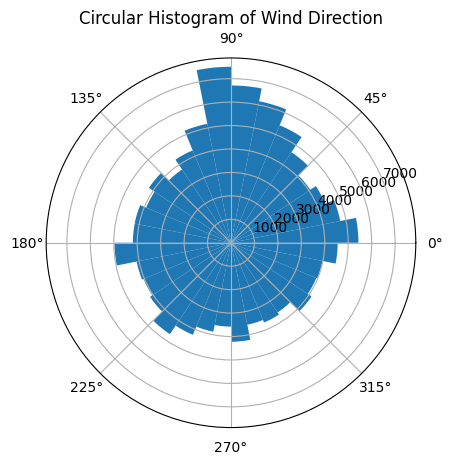

In [149]:
# Needs circular plots and directional statistics (not linear)

# Convert degrees to radians
angles = np.deg2rad(df['wind_degree'])

# Create bins
num_bins = 32
bins = np.linspace(0, 2 * np.pi, num_bins + 1)

# Count frequencies
counts, _ = np.histogram(angles, bins=bins)

# Plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

ax.bar(
    bins[:-1],
    counts,
    width=(2 * np.pi / num_bins),
    align='edge'
)

ax.set_title('Circular Histogram of Wind Direction')

plt.show()

In [150]:
# Check if the above plot is consistent with 16 point wind_direction

df['wind_direction'].unique()

<StringArray>
['NNW',  'NW',   'W',  'SW', 'SSE',   'E',   'N',  'SE', 'ESE', 'NNE',   'S',
 'WSW', 'SSW', 'ENE',  'NE', 'WNW']
Length: 16, dtype: str

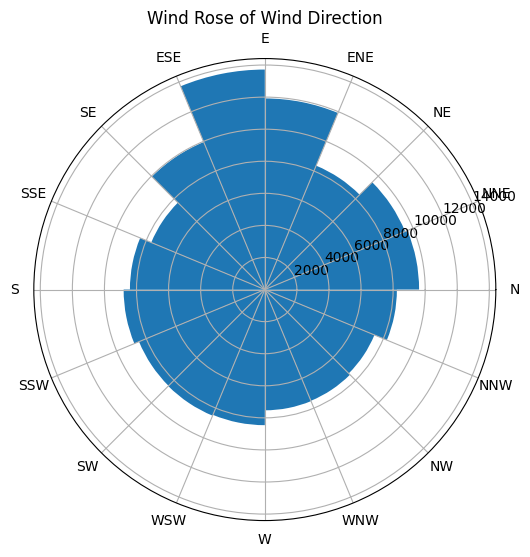

In [151]:
# Order compass directions properly
directions = [
    'N', 'NNE', 'NE', 'ENE',
    'E', 'ESE', 'SE', 'SSE',
    'S', 'SSW', 'SW', 'WSW',
    'W', 'WNW', 'NW', 'NNW'
]

# Count frequencies
counts = df['wind_direction'].value_counts()

# Ensure consistent order
counts = [counts.get(d, 0) for d in directions]

# Angles
angles = np.linspace(0, 2 * np.pi, len(directions), endpoint=False)

# Plot
fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection': 'polar'})

ax.bar(
    angles,
    counts,
    width=2*np.pi/len(directions),
    align='edge'
)

# Labels
ax.set_xticks(angles)
ax.set_xticklabels(directions)

ax.set_title('Wind Rose of Wind Direction')

plt.show()

Both the continuous circular histogram (`wind_degree`) and the categorical wind rose (`wind_direction`) showed similar directional distributions, indicating internal consistency between the two representations. No obvious anomalous or invalid directional values were observed.

### Pressure related features

In [152]:
df['pressure_mb'].describe()

count    144040.000000
mean       1014.052680
std          10.157057
min         947.000000
25%        1010.000000
50%        1013.000000
75%        1018.000000
max        3006.000000
Name: pressure_mb, dtype: float64

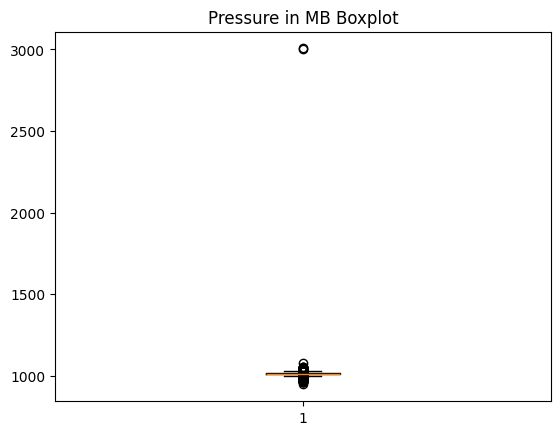

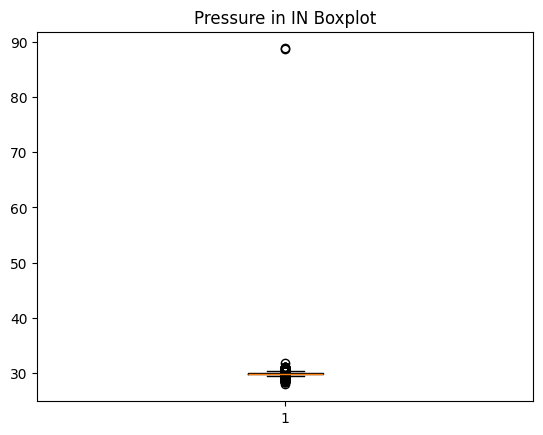

In [153]:
# boxplots for pressure
# IQR method to detect outliers

pressure_columns = ['pressure_mb', 'pressure_in']

for col in pressure_columns:
    plt.boxplot(df[col])
    plt.title(f'{col.split("_")[0].title()} in {col.split("_")[1].upper()} Boxplot')
    plt.show()

In [154]:
df[df['pressure_mb'] > 1500]

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
49769,Honduras,Tegucigalpa,14.1000,-87.2167,America/Tegucigalpa,1738062000,2025-01-28 05:00:00,19.1,66.4,Partly cloudy,6.5,10.4,15,NNE,3006.0,88.77,0.02,0.0,88,50,19.1,66.4,10.0,6.0,0.0,11.4,18.3,329.30,77.0,2.035,1.48,6.66,8.140,1,1,2026-05-28 06:17:00,2026-05-28 17:47:00,2026-05-28 05:39:00,2026-05-28 17:11:00,Waning Crescent,2
52114,Iran,Tehran,35.7261,51.3304,Asia/Tehran,1739097000,2025-02-09 14:00:00,2.1,35.8,Overcast,5.1,8.3,268,W,3000.0,88.59,0.02,0.0,60,100,-0.4,31.4,9.0,5.0,1.6,5.9,9.5,3146.85,40.0,118.030,56.61,51.43,52.725,3,6,2026-05-28 06:58:00,2026-05-28 17:41:00,2026-05-28 14:17:00,2026-05-28 04:54:00,Waxing Gibbous,85


In [155]:
df[df['pressure_in'] > 40]

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
49769,Honduras,Tegucigalpa,14.1000,-87.2167,America/Tegucigalpa,1738062000,2025-01-28 05:00:00,19.1,66.4,Partly cloudy,6.5,10.4,15,NNE,3006.0,88.77,0.02,0.0,88,50,19.1,66.4,10.0,6.0,0.0,11.4,18.3,329.30,77.0,2.035,1.48,6.66,8.140,1,1,2026-05-28 06:17:00,2026-05-28 17:47:00,2026-05-28 05:39:00,2026-05-28 17:11:00,Waning Crescent,2
52114,Iran,Tehran,35.7261,51.3304,Asia/Tehran,1739097000,2025-02-09 14:00:00,2.1,35.8,Overcast,5.1,8.3,268,W,3000.0,88.59,0.02,0.0,60,100,-0.4,31.4,9.0,5.0,1.6,5.9,9.5,3146.85,40.0,118.030,56.61,51.43,52.725,3,6,2026-05-28 06:58:00,2026-05-28 17:41:00,2026-05-28 14:17:00,2026-05-28 04:54:00,Waxing Gibbous,85


In [156]:
# Removing the extreme outliers in pressure_mb and pressure_in

df = df[df['pressure_mb'] < 1500]

In [157]:
df.shape

(144038, 41)

### Precipitation related features

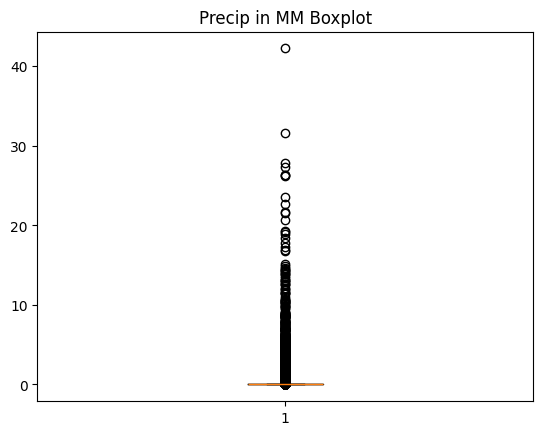

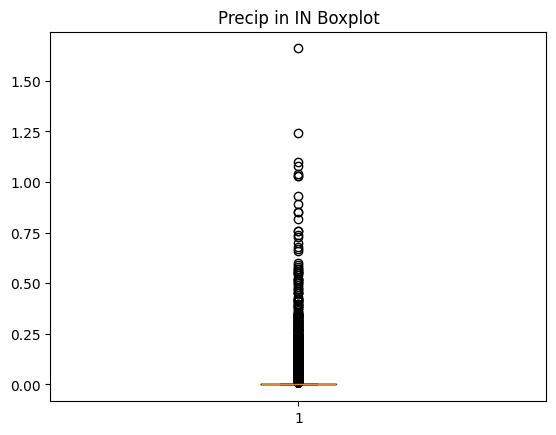

In [158]:
precipitation_columns = ['precip_mm', 'precip_in']
for col in precipitation_columns:
    plt.boxplot(df[col])
    plt.title(f'{col.split("_")[0].title()} in {col.split("_")[1].upper()} Boxplot')
    plt.show()

The precipitation variables exhibited highly zero-inflated distributions, with a large proportion of observations corresponding to no rainfall. As a result, the IQR bounds collapsed near zero, causing most nonzero precipitation measurements to be statistically flagged as outliers. Since rainfall naturally follows a sparse and heavily right-skewed distribution, these observations were retained and not treated as anomalous records.

(array([3.5879e+04, 5.3750e+03, 2.7730e+03, 1.4720e+03, 8.7400e+02,
        4.8500e+02, 2.8800e+02, 1.5500e+02, 1.0000e+02, 6.5000e+01,
        6.7000e+01, 5.1000e+01, 3.6000e+01, 2.3000e+01, 1.9000e+01,
        7.0000e+00, 1.6000e+01, 9.0000e+00, 9.0000e+00, 8.0000e+00,
        1.1000e+01, 5.0000e+00, 3.0000e+00, 4.0000e+00, 6.0000e+00,
        3.0000e+00, 2.0000e+00, 3.0000e+00, 3.0000e+00, 3.0000e+00,
        3.0000e+00, 2.0000e+00, 3.0000e+00, 3.0000e+00, 3.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        2.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 2.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 3.0000e+00, 0.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

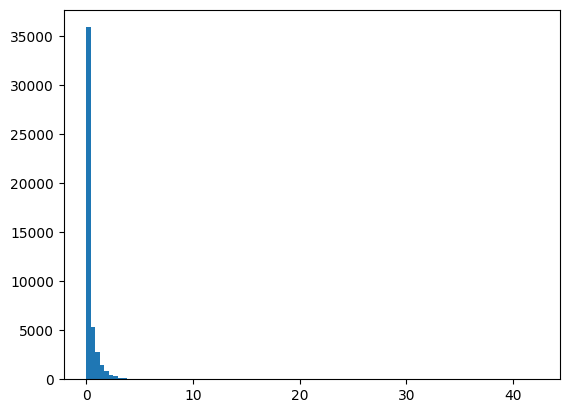

In [159]:
# plot actual precipitation distribution

df_rain = df[df['precip_mm'] > 0]
plt.hist(df_rain['precip_mm'], bins=100)

In [160]:
df_rain['precip_mm'].describe()

count    47790.000000
mean         0.399914
std          0.915019
min          0.010000
25%          0.030000
50%          0.100000
75%          0.430000
max         42.240000
Name: precip_mm, dtype: float64

(array([   8.,   40.,   29.,   69.,  113.,  117.,  154.,  211.,  238.,
         471.,  615.,  607., 1215., 1126., 1864., 2396., 2227., 3787.,
        4660., 4760., 5507., 5869.,  905., 6810., 3992.]),
 array([  9.  ,  12.64,  16.28,  19.92,  23.56,  27.2 ,  30.84,  34.48,
         38.12,  41.76,  45.4 ,  49.04,  52.68,  56.32,  59.96,  63.6 ,
         67.24,  70.88,  74.52,  78.16,  81.8 ,  85.44,  89.08,  92.72,
         96.36, 100.  ]),
 <BarContainer object of 25 artists>)

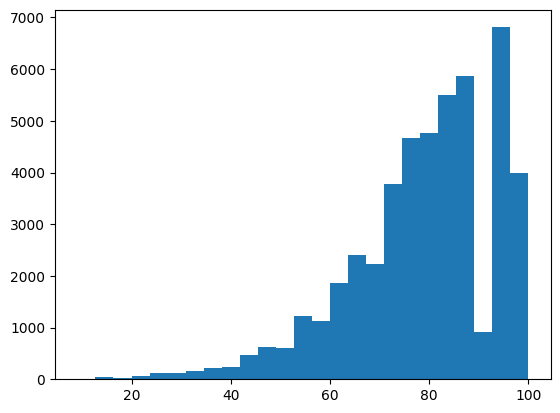

In [161]:
plt.hist(df_rain['humidity'], bins=25)

In [162]:
df['humidity'].describe()

count    144038.000000
mean         66.788639
std          23.762503
min           2.000000
25%          51.000000
50%          72.000000
75%          86.000000
max         100.000000
Name: humidity, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1cbbef2e1b0>,
 'caps': [<matplotlib.lines.Line2D at 0x1cbbe3d0680>,
 'boxes': [<matplotlib.lines.Line2D at 0x1cbbef2df40>],
 'medians': [<matplotlib.lines.Line2D at 0x1cbbef2e5d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1cbbef2e900>],
 'means': []}

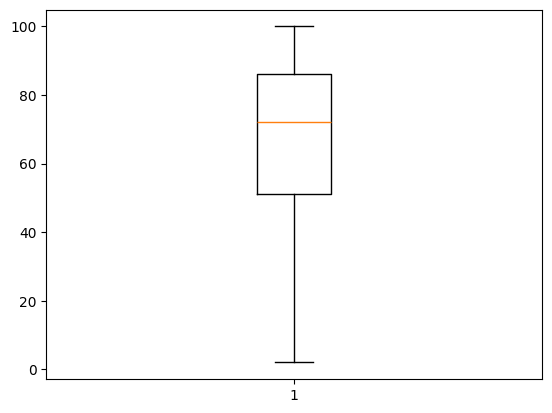

In [163]:
# boxplot for humidity
plt.boxplot(df['humidity'])

In [164]:
df['cloud'].describe()

count    144038.000000
mean         39.752538
std          34.068310
min           0.000000
25%           0.000000
50%          29.000000
75%          75.000000
max         100.000000
Name: cloud, dtype: float64

(array([1.7290e+03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 5.5950e+03, 0.0000e+00, 0.0000e+00, 2.0000e+02,
        0.0000e+00, 1.0000e+00, 7.8130e+03, 6.1900e+02, 6.2900e+02,
        8.1900e+02, 4.9100e+02, 1.2510e+03, 1.5633e+04, 1.8340e+03,
        1.8480e+03, 1.7310e+03, 9.8800e+02, 2.4900e+02, 6.3600e+03]),
 array([  0.,   4.,   8.,  12.,  16.,  20.,  24.,  28.,  32.,  36.,  40.,
         44.,  48.,  52.,  56.,  60.,  64.,  68.,  72.,  76.,  80.,  84.,
         88.,  92.,  96., 100.]),
 <BarContainer object of 25 artists>)

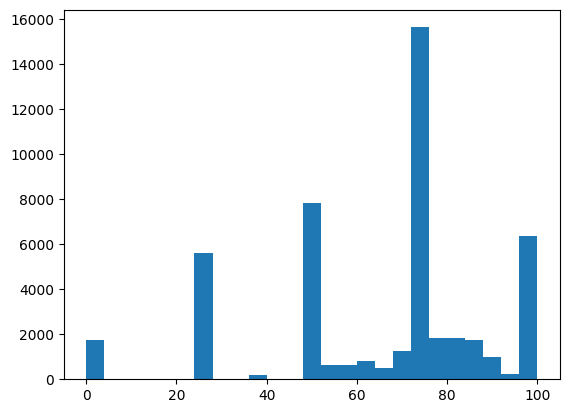

In [165]:
plt.hist(df_rain['cloud'], bins=25)

{'whiskers': [<matplotlib.lines.Line2D at 0x1cbbe111370>,
 'caps': [<matplotlib.lines.Line2D at 0x1cbbcf85c70>,
 'boxes': [<matplotlib.lines.Line2D at 0x1cbbe1110a0>],
 'medians': [<matplotlib.lines.Line2D at 0x1cbbeed26f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1cbbeefdcd0>],
 'means': []}

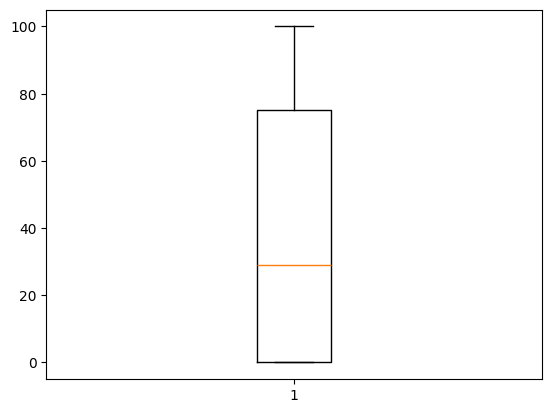

In [166]:
# boxplot for cloud
plt.boxplot(df['cloud'])

### Other features

#### Visibility

In [167]:
df['visibility_km'].describe()

count    144038.000000
mean          9.514689
std           2.685356
min           0.000000
25%          10.000000
50%          10.000000
75%          10.000000
max          32.000000
Name: visibility_km, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1cbbe3c39b0>,
 'caps': [<matplotlib.lines.Line2D at 0x1cbbe3c1e20>,
 'boxes': [<matplotlib.lines.Line2D at 0x1cbbe3c3980>],
 'medians': [<matplotlib.lines.Line2D at 0x1cbbcf351c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1cbbdeebc80>],
 'means': []}

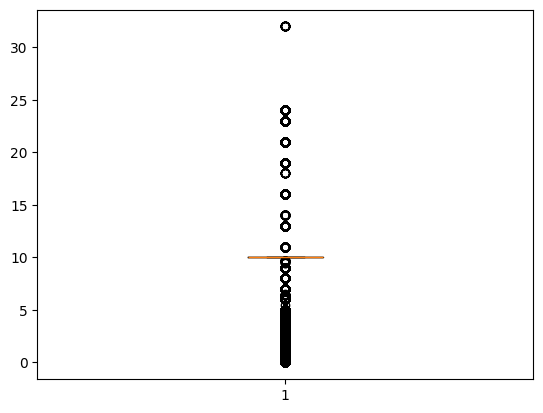

In [168]:
# boxplot for visibility_km
plt.boxplot(df['visibility_km'])

In [169]:
df['visibility_miles'].describe()

count    144038.000000
mean          5.621475
std           1.676865
min           0.000000
25%           6.000000
50%           6.000000
75%           6.000000
max          19.000000
Name: visibility_miles, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1cbbde84ef0>,
 'caps': [<matplotlib.lines.Line2D at 0x1cbbde84770>,
 'boxes': [<matplotlib.lines.Line2D at 0x1cbbde85190>],
 'medians': [<matplotlib.lines.Line2D at 0x1cbbde85a30>],
 'fliers': [<matplotlib.lines.Line2D at 0x1cbbde86030>],
 'means': []}

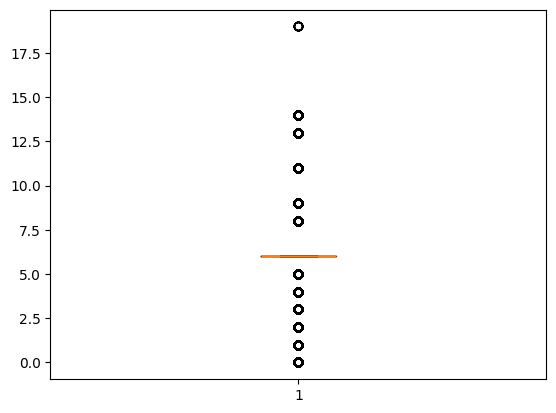

In [170]:
plt.boxplot(df['visibility_miles'])

(array([1.50100e+03, 3.98000e+02, 3.61000e+02, 2.15500e+03, 7.52000e+02,
        5.04000e+02, 1.29800e+03, 3.12600e+03, 1.00000e+00, 2.76700e+03,
        3.08400e+03, 0.00000e+00, 5.17800e+03, 0.00000e+00, 5.78600e+03,
        1.13498e+05, 0.00000e+00, 1.17000e+02, 0.00000e+00, 0.00000e+00,
        1.79000e+02, 5.20000e+01, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        9.42000e+02, 0.00000e+00, 0.00000e+00, 1.20000e+01, 2.05000e+02,
        0.00000e+00, 0.00000e+00, 2.69000e+02, 0.00000e+00, 0.00000e+00,
        2.17000e+02, 0.00000e+00, 1.61800e+03, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.80000e+01]),
 array([ 0.  ,  0.64,  1.28,  1.92,  2.56,  3.2 ,  3.84,  4.48,  5.12,
         5.76,  6.4 ,  7.04,  7.68,  8.32,  8.96,  9.6 , 10.24, 10.88,
        11.52, 12.16, 12.8 , 13.44, 14.08, 14.72, 15.36, 16.  , 16.64,
        17.28, 17.92, 18.56, 19.2 , 19.84, 20.48, 21.12

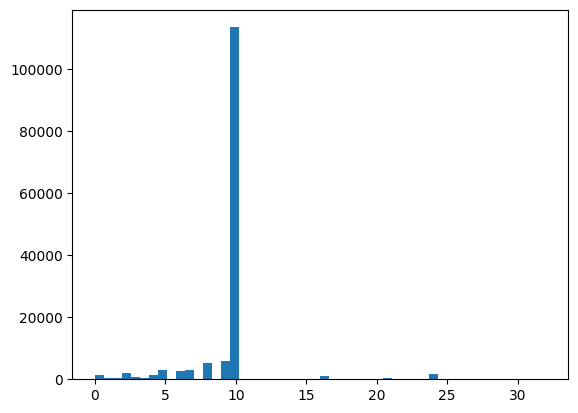

In [171]:
# histogram for visibility_km
plt.hist(df['visibility_km'], bins=50)

In [172]:
df[df['visibility_km'] > 20][
    ['country', 'location_name', 'visibility_km', 'visibility_miles']
].sort_values('visibility_km', ascending=False).drop_duplicates().head(20)

,country,location_name,visibility_km,visibility_miles
51752,Marshall Islands,Majuro,32.0,19.0
88189,Micronesia,Palikir,32.0,19.0
141735,Canada,Ottawa,24.0,14.0
141810,Marshall Islands,Majuro,24.0,14.0
142009,Micronesia,Palikir,24.0,14.0
1883,Palau,Meyungs,24.0,14.0
3247,Palau,Adkip,24.0,14.0
8857,Palau,Koror,24.0,14.0
17555,Palau,Airai,24.0,14.0
132,Palau,Meyungs,23.0,14.0


#### UV

In [173]:
df['uv_index'].describe()

count    144038.000000
mean          3.255982
std           3.531825
min           0.000000
25%           0.100000
50%           1.800000
75%           6.000000
max          16.300000
Name: uv_index, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1cbbdaece00>,
 'caps': [<matplotlib.lines.Line2D at 0x1cbbdaef200>,
 'boxes': [<matplotlib.lines.Line2D at 0x1cbbdaed520>],
 'medians': [<matplotlib.lines.Line2D at 0x1cbbdaeecc0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1cbbdaec7a0>],
 'means': []}

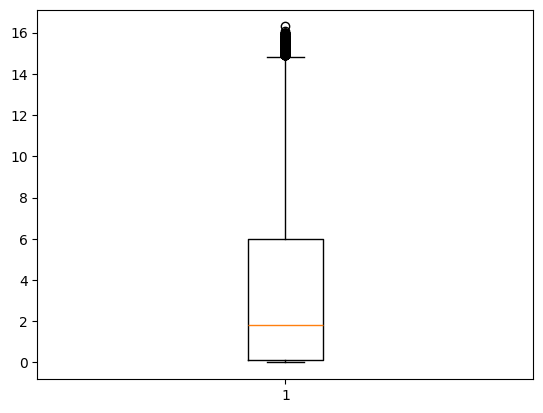

In [174]:
# boxplot for uv_index
plt.boxplot(df['uv_index'])

(array([55005., 15855.,  7996.,  6885.,  7222.,  4640.,  7198.,  9422.,
         8225.,  6543.,  2368.,  4042.,  2903.,  2141.,  1398.,   860.,
          613.,   428.,   236.,    58.]),
 array([ 0.   ,  0.815,  1.63 ,  2.445,  3.26 ,  4.075,  4.89 ,  5.705,
         6.52 ,  7.335,  8.15 ,  8.965,  9.78 , 10.595, 11.41 , 12.225,
        13.04 , 13.855, 14.67 , 15.485, 16.3  ]),
 <BarContainer object of 20 artists>)

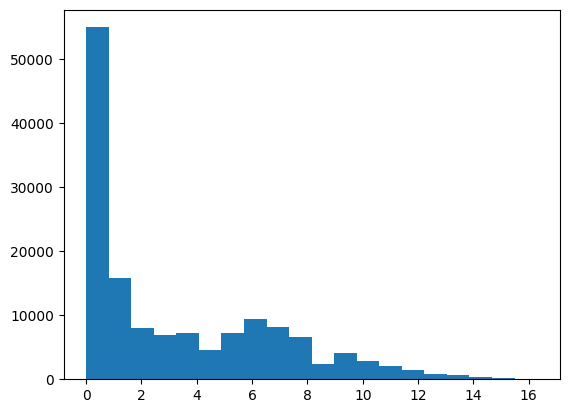

In [175]:
#histogram for uv_index
plt.hist(df['uv_index'], bins=20)

In [176]:
df[['country', 'location_name', 'uv_index']].sort_values('uv_index', ascending=False).drop_duplicates().head(20)

,country,location_name,uv_index
52423,Zambia,Lusaka,16.3
47518,South Africa,Pretoria,16.1
53890,Malawi,Lilongwe,16.0
45544,Madagascar,Antananarivo,16.0
47356,Zimbabwe,Harare,16.0
60111,Kenya,Nairobi,16.0
58520,Ethiopia,Addis Ababa,16.0
53981,Zambia,Lusaka,16.0
57007,Madagascar,Antananarivo,15.9
58715,Ethiopia,Addis Ababa,15.9


### Air pollution features

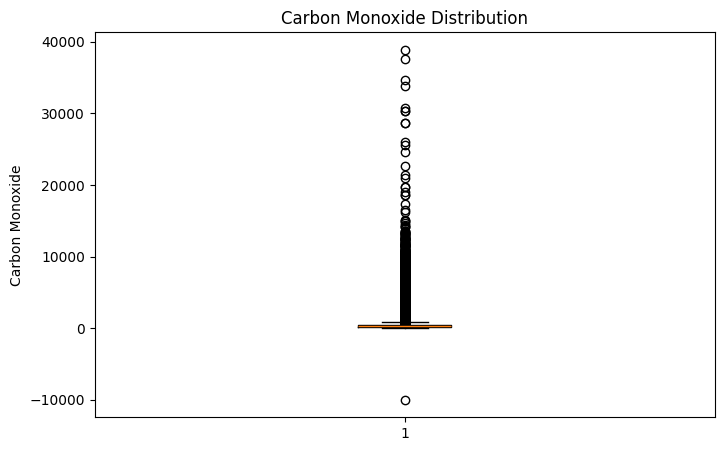

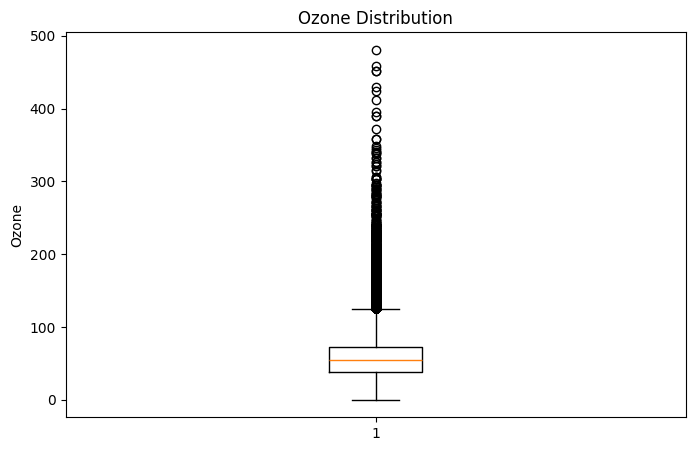

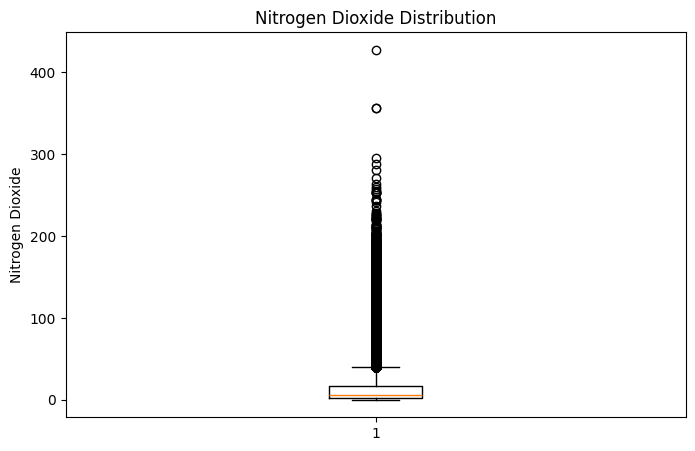

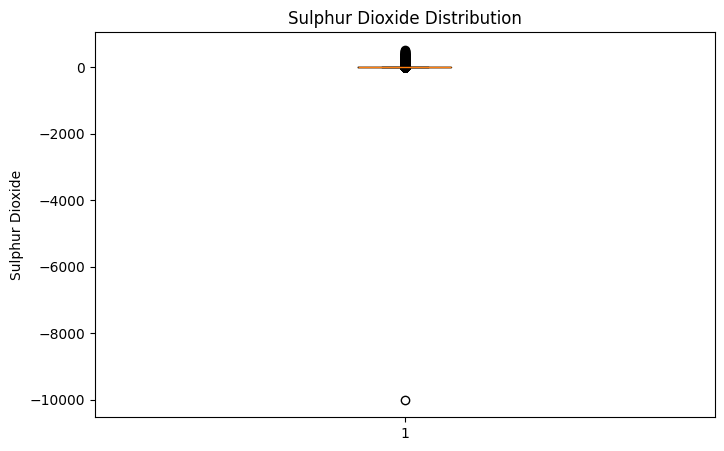

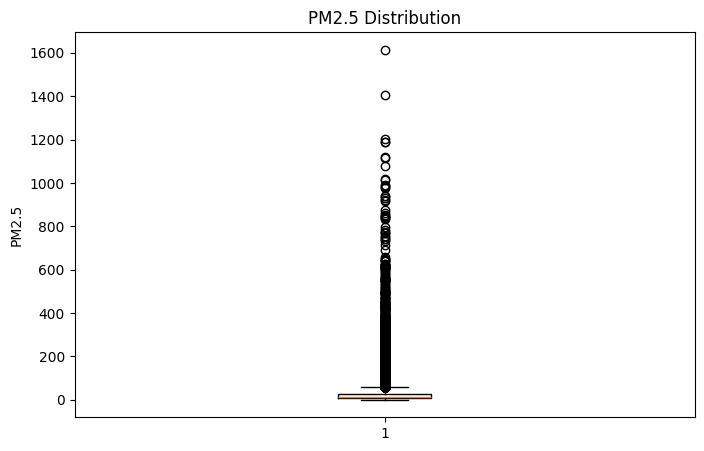

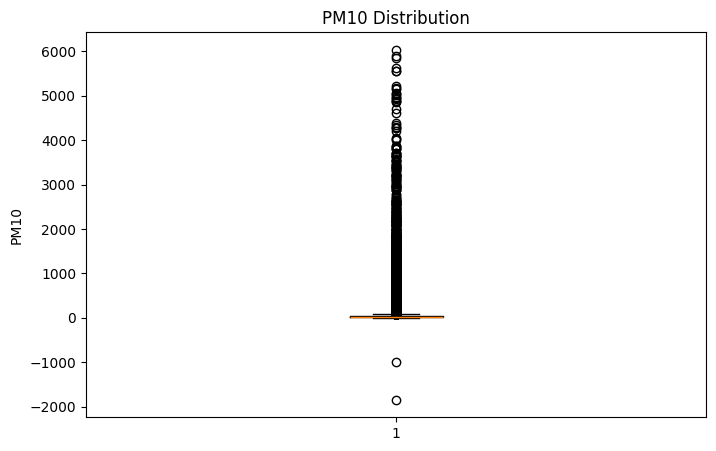

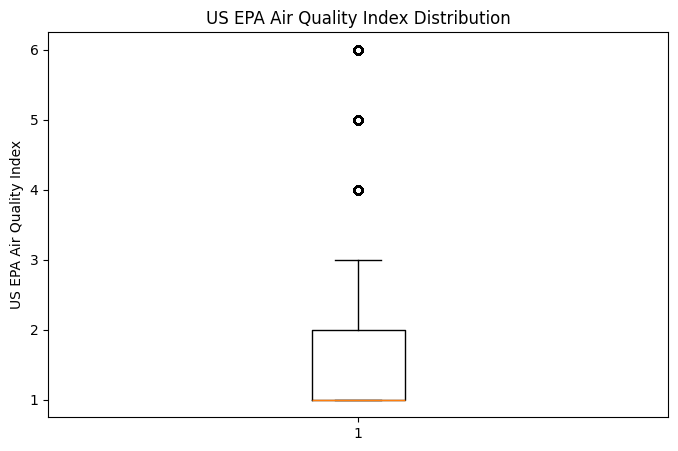

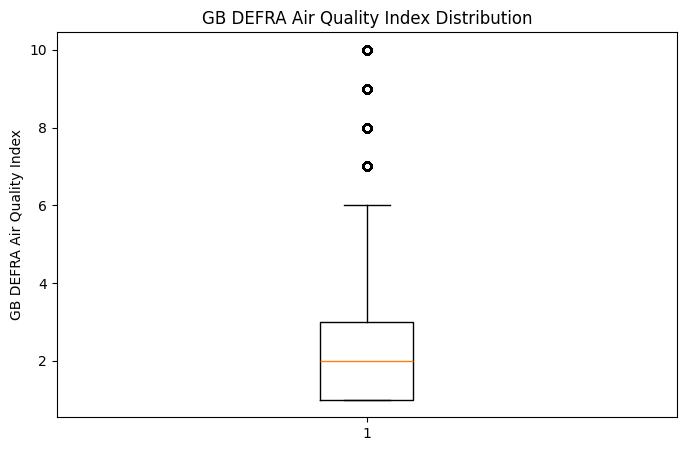

In [177]:
air_pollution_columns = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_us-epa-index',
    'air_quality_gb-defra-index'
]

title_map = {
    'air_quality_Carbon_Monoxide': 'Carbon Monoxide',
    'air_quality_Ozone': 'Ozone',
    'air_quality_Nitrogen_dioxide': 'Nitrogen Dioxide',
    'air_quality_Sulphur_dioxide': 'Sulphur Dioxide',
    'air_quality_PM2.5': 'PM2.5',
    'air_quality_PM10': 'PM10',
    'air_quality_us-epa-index': 'US EPA Air Quality Index',
    'air_quality_gb-defra-index': 'GB DEFRA Air Quality Index'
}

for col in air_pollution_columns:
    plt.figure(figsize=(8,5))
    plt.boxplot(df[col])
    plt.title(f'{title_map[col]} Distribution')
    plt.ylabel(title_map[col])
    plt.show()


In [178]:
for col in air_pollution_columns:
    print(f"Description for {title_map[col]}:")
    print(df[col].describe())

Description for Carbon Monoxide:
count    144038.000000
mean        448.340368
std         741.401800
min       -9999.000000
25%         194.250000
50%         286.750000
75%         449.550000
max       38879.398000
Name: air_quality_Carbon_Monoxide, dtype: float64
Description for Ozone:
count    144038.000000
mean         57.480498
std          30.372864
min           0.000000
25%          38.000000
50%          55.000000
75%          73.000000
max         480.700000
Name: air_quality_Ozone, dtype: float64
Description for Nitrogen Dioxide:
count    144038.000000
mean         14.787585
std          23.274342
min           0.000000
25%           1.800000
50%           5.735000
75%          17.020000
max         427.700000
Name: air_quality_Nitrogen_dioxide, dtype: float64
Description for Sulphur Dioxide:
count    144038.000000
mean         10.092523
std          34.670083
min       -9999.000000
25%           1.110000
50%           2.405000
75%           8.050000
max         521.330000


In [179]:
print(np.sort(df['air_quality_us-epa-index'].unique()))
print(np.sort(df['air_quality_gb-defra-index'].unique()))

[1 2 3 4 5 6]
[ 1  2  3  4  5  6  7  8  9 10]


- The features corresponding to carbon monoxide, ozone, nitrogen dioxide, sulphur dioxide, particulate matters 2.5 and 10 are all continuous values and represent concentrations. They cannot be negative.
- The 2 AQIs (US EPA and GB DEFRA) are discrete. 

In [180]:
# Carbon Monoxide

df = df[(df['air_quality_Carbon_Monoxide'] >= 0)]
df.shape

(144037, 41)

In [181]:
df[df['air_quality_Carbon_Monoxide'] > 30000][
    ['country', 'location_name', 'air_quality_Carbon_Monoxide']
].sort_values('air_quality_Carbon_Monoxide', ascending=False).drop_duplicates()

,country,location_name,air_quality_Carbon_Monoxide
6695,Indonesia,Jakarta,38879.398
1244,Indonesia,Jakarta,37597.699
5336,Indonesia,Jakarta,34606.898
9388,Indonesia,Jakarta,33752.398
5531,Indonesia,Jakarta,30761.699
5141,Indonesia,Jakarta,30334.500


In [182]:
# Ozone

df = df[(df['air_quality_Ozone'] >= 0)]
df.shape

(144037, 41)

In [183]:
df[df['air_quality_Ozone'] > 300][
    ['country', 'location_name', 'air_quality_Ozone']
].sort_values('air_quality_Ozone', ascending=False).drop_duplicates()

,country,location_name,air_quality_Ozone
17045,Bahrain,Manama,480.7
6632,Bahrain,Manama,457.8
19775,Bahrain,Manama,452.0
20099,Qatar,Doha,452.0
16070,Bahrain,Manama,429.2
21334,Bahrain,Manama,423.4
11263,Angola,Luanda,412.0
8932,Bahrain,Manama,394.8
9899,Angola,Luanda,389.1
20157,Angola,Luanda,371.9


In [184]:
# Nitrogen Dioxide

df = df[(df['air_quality_Nitrogen_dioxide'] >= 0)]
df.shape

(144037, 41)

In [185]:
df[df['air_quality_Nitrogen_dioxide'] > 250][
    ['country', 'location_name', 'air_quality_Nitrogen_dioxide']
].sort_values('air_quality_Nitrogen_dioxide', ascending=False).drop_duplicates()

,country,location_name,air_quality_Nitrogen_dioxide
5556,Malaysia,Kuala Lumpur,427.700
28032,Iraq,Baghdad,357.050
9413,Malaysia,Kuala Lumpur,356.400
28616,Iraq,Baghdad,295.815
74470,Chile,Santiago,287.860
42989,Iraq,Baghdad,281.015
10778,Malaysia,Kuala Lumpur,271.400
16136,Indonesia,Jakarta,263.200
480,Kuwait,Kuwait City,260.500
29201,Iraq,Baghdad,257.890


In [186]:
# Suplhur Dioxide
df = df[(df['air_quality_Sulphur_dioxide'] >= 0)]
df.shape

(144036, 41)

Text(0.5, 1.0, 'Sulphur Dioxide Distribution')

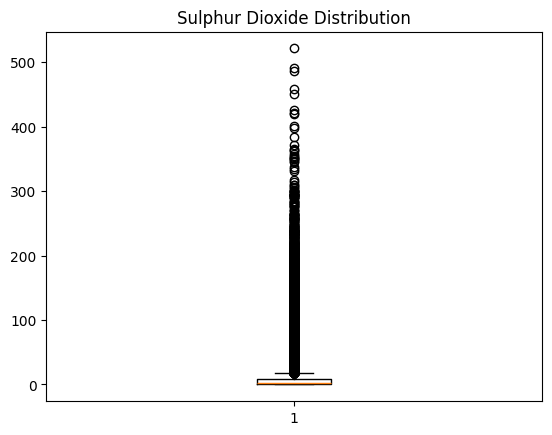

In [187]:
# box plot
plt.boxplot(df['air_quality_Sulphur_dioxide'])
plt.title('Sulphur Dioxide Distribution')

In [188]:
df[df['air_quality_Sulphur_dioxide'] > 350][
    ['country', 'location_name', 'air_quality_Sulphur_dioxide']
].sort_values('air_quality_Sulphur_dioxide', ascending=False).drop_duplicates()

,country,location_name,air_quality_Sulphur_dioxide
46823,Egypt,Cairo,521.330
54906,Russia,Moscow,491.730
49147,China,Beijing,486.180
42945,China,Beijing,457.690
47018,Egypt,Cairo,451.215
40605,China,Beijing,425.130
44159,Iraq,Baghdad,421.800
46043,Egypt,Cairo,420.135
36120,China,Beijing,400.340
47213,Egypt,Cairo,398.120


In [189]:
# PM 2.5

df = df[(df['air_quality_PM2.5'] >= 0)]
df.shape

(144036, 41)

In [190]:
df[df['air_quality_PM2.5'] > 750][
    ['country', 'location_name', 'air_quality_PM2.5']
].sort_values('air_quality_PM2.5', ascending=False).drop_duplicates()

,country,location_name,air_quality_PM2.5
4125,Chile,Santiago,1614.1
4513,Chile,Santiago,1406.3
12219,Chile,Santiago,1204.9
3930,Chile,Santiago,1190.5
14338,Chile,Santiago,1188.4
9540,Chile,Santiago,1119.7
9345,Chile,Santiago,1116.0
2955,Chile,Santiago,1078.5
3150,Chile,Santiago,1018.7
3735,Chile,Santiago,1012.9


In [191]:
# PM 10
df = df[(df['air_quality_PM10'] >= 0)]
df.shape

(144034, 41)

In [192]:
df[df['air_quality_PM10'] > 3500][
    ['country', 'location_name', 'air_quality_PM10']
].sort_values('air_quality_PM10', ascending=False).drop_duplicates()

,country,location_name,air_quality_PM10
51796,Saudi Arabia,Riyadh,6037.29
51601,Saudi Arabia,Riyadh,5899.28
41305,Saudi Arabia,Riyadh,5858.02
68948,Saudi Arabia,Riyadh,5623.63
42475,Saudi Arabia,Riyadh,5554.81
40330,Saudi Arabia,Riyadh,5224.03
45594,Saudi Arabia,Riyadh,5182.59
70508,Saudi Arabia,Riyadh,5155.02
52771,Saudi Arabia,Riyadh,5072.33
45948,Saudi Arabia,Riyadh,5044.77


### Moon features

In [193]:
df['moon_illumination'].describe()

count    144034.000000
mean         49.708944
std          35.014293
min           0.000000
25%          15.000000
50%          50.000000
75%          84.000000
max         100.000000
Name: moon_illumination, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1cbc0412cc0>,
 'caps': [<matplotlib.lines.Line2D at 0x1cbc04130e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1cbc0412a20>],
 'medians': [<matplotlib.lines.Line2D at 0x1cbc04136b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1cbc04139b0>],
 'means': []}

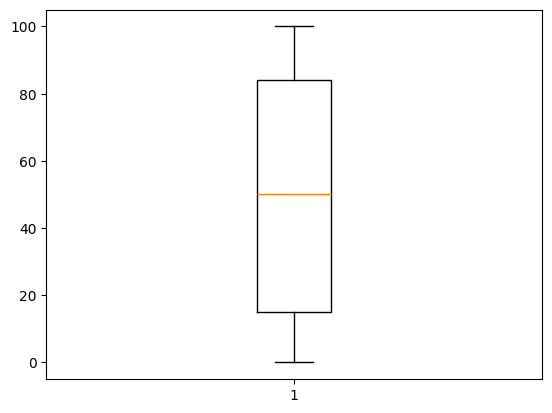

In [194]:
# boxplot for moon_illumination
plt.boxplot(df['moon_illumination'])

(array([18977.,  9558.,  6789.,  6209.,  5762.,  5312.,  5069.,  4698.,
         4782.,  4767.,  4690.,  5001.,  4944.,  5296.,  4912.,  5449.,
         5920.,  6926.,  8378., 20595.]),
 array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
         55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100.]),
 <BarContainer object of 20 artists>)

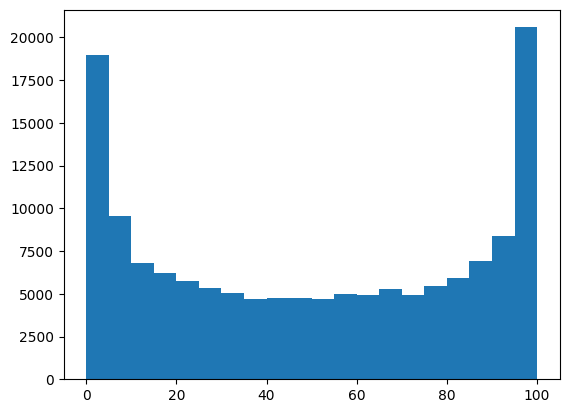

In [195]:
# hist for moon_illumination
plt.hist(df['moon_illumination'], bins=20)

In [196]:
# moon_phase

df['moon_phase'].unique()

<StringArray>
[ 'Waxing Gibbous',       'Full Moon',  'Waning Gibbous',    'Last Quarter',
 'Waning Crescent',        'New Moon', 'Waxing Crescent',   'First Quarter']
Length: 8, dtype: str

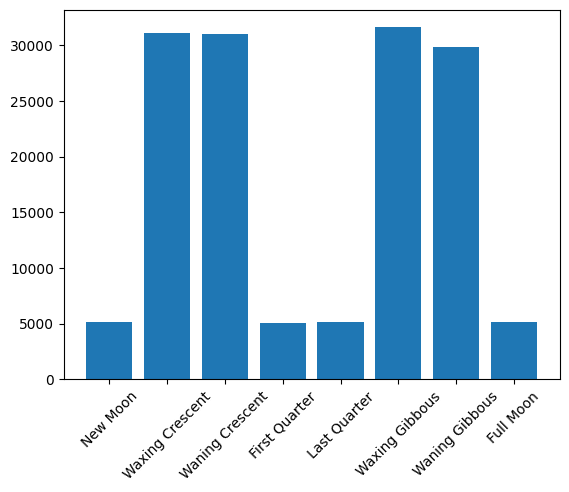

In [197]:
moon_phase_order = [
    'New Moon',
    'Waxing Crescent',
    'Waning Crescent',
    'First Quarter',
    'Last Quarter',
    'Waxing Gibbous',
    'Waning Gibbous',
    'Full Moon',
]

counts = (
    df['moon_phase']
    .value_counts()
    .reindex(moon_phase_order)
)

plt.bar(counts.index, counts.values)
plt.xticks(rotation=45)
plt.show()

# Save resulting data

In [198]:
# save cleaned df in a csv

df.to_csv('global_weather_cleaned.csv', index=False)